In [3]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [33]:
import os
import shutil

from_path = "/content/drive/MyDrive/retinopathy"
to_path = "/content/drive/MyDrive/new_retinopathy"

# Define mappings
yes_classes = ['Mild', 'Moderate', 'Severe', 'Proliferate_DR']
no_classes = ['No_DR']

# Create folders
os.makedirs(os.path.join(to_path, 'Yes'), exist_ok=True)
os.makedirs(os.path.join(to_path, 'No'), exist_ok=True)

# Copy files to Yes
for cls in yes_classes:
    class_path = os.path.join(from_path, cls)
    for fname in os.listdir(class_path):
        src = os.path.join(class_path, fname)
        dst = os.path.join(to_path, 'Yes', f"{cls}_{fname}")
        shutil.copyfile(src, dst)

# Copy files to No
for cls in no_classes:
    class_path = os.path.join(from_path, cls)
    for fname in os.listdir(class_path):
        src = os.path.join(class_path, fname)
        dst = os.path.join(to_path, 'No', f"{cls}_{fname}")
        shutil.copyfile(src, dst)

print("✅ Dataset converted to binary format (Yes/No).")

✅ Dataset converted to binary format (Yes/No).


In [35]:
import os
import shutil
import random
from tqdm import tqdm

# Source directory (binary classification dataset)
src_dir = '/content/drive/MyDrive/new_retinopathy'

# Destination directories
base_dir = '/content/drive/MyDrive/new_retinopathy_split'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# Make directories
for split in ['train', 'val', 'test']:
    for class_name in ['Yes', 'No']:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Function to split data
def split_data(class_name):
    class_path = os.path.join(src_dir, class_name)
    images = os.listdir(class_path)
    random.shuffle(images)

    total = len(images)
    train_count = int(total * train_ratio)
    val_count = int(total * val_ratio)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    for image in tqdm(train_images, desc=f'Copying {class_name} train'):
        shutil.copy(os.path.join(class_path, image), os.path.join(train_dir, class_name, image))

    for image in tqdm(val_images, desc=f'Copying {class_name} val'):
        shutil.copy(os.path.join(class_path, image), os.path.join(val_dir, class_name, image))

    for image in tqdm(test_images, desc=f'Copying {class_name} test'):
        shutil.copy(os.path.join(class_path, image), os.path.join(test_dir, class_name, image))

# Split both classes
split_data('Yes')
split_data('No')

Copying No test: 100%|██████████| 272/272 [00:02<00:00, 104.20it/s]


In [36]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os

In [37]:
# Dataset directories
train_dir = '/content/drive/MyDrive/new_retinopathy_split/train'
val_dir   = '/content/drive/MyDrive/new_retinopathy_split/val'
test_dir  = '/content/drive/MyDrive/new_retinopathy_split/test'

# Model parameters
img_size = (224, 224)
batch_size = 32
epochs = 25

In [38]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

val_gen = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

test_gen = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 2562 images belonging to 2 classes.
Found 548 images belonging to 2 classes.
Found 552 images belonging to 2 classes.


In [39]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze base model
base_model.trainable = False

# Custom top layers
x = GlobalAveragePooling2D()(base_model.output)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [40]:
checkpoint_path = "best_binary_resnet_model.keras"
checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=epochs,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.5012 - loss: 0.7678
Epoch 1: val_accuracy improved from -inf to 0.50730, saving model to best_binary_resnet_model.keras
81/81 ━━━━━━━━━━━━━━━━━━━━ 72s 754ms/step - accuracy: 0.5014 - loss: 0.7674 - val_accuracy: 0.5073 - val_loss: 0.6891
Epoch 2/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 506ms/step - accuracy: 0.5205 - loss: 0.7014
Epoch 2: val_accuracy did not improve from 0.50730
81/81 ━━━━━━━━━━━━━━━━━━━━ 46s 571ms/step - accuracy: 0.5205 - loss: 0.7013 - val_accuracy: 0.4927 - val_loss: 0.6827
Epoch 3/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.5330 - loss: 0.6936
Epoch 3: val_accuracy did not improve from 0.50730
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 537ms/step - accuracy: 0.5329 - loss: 0.6936 - val_accuracy: 0.4927 - val_loss: 0.6812
Epoch 4/25
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.5547 - loss: 0.6909
Epoch 4: val_accuracy improved from 0.50730 to 0.72993, saving model to best_binary_resnet_model.ker

In [41]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 354ms/step - accuracy: 0.8216 - loss: 0.5273
Test Accuracy: 86.23%


In [42]:
model.save('/content/drive/MyDrive/retinopathy/retinopathy_base_classification.keras')

In [44]:
# 1. Unfreeze the top layers of ResNet50 base
base_model.trainable = True

# 2. Freeze most of the layers — fine-tune only last N layers
fine_tune_at = 140
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# 3. Compile the model with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Setup callbacks (optional: continue using early stopping and checkpoint)
checkpoint = ModelCheckpoint('finetuned_resnet_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# 5. Fine-tune the model
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,  # fewer epochs for fine-tuning
    callbacks=[checkpoint, early_stop]
)

Epoch 1/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.6361 - loss: 4.0628 - val_accuracy: 0.4927 - val_loss: 1.6483
Epoch 2/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 537ms/step - accuracy: 0.8038 - loss: 0.6667 - val_accuracy: 0.4927 - val_loss: 4.4016
Epoch 3/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 537ms/step - accuracy: 0.8437 - loss: 0.4368 - val_accuracy: 0.4927 - val_loss: 4.3709
Epoch 4/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 44s 547ms/step - accuracy: 0.8510 - loss: 0.3747 - val_accuracy: 0.4927 - val_loss: 2.0894
Epoch 5/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 82s 551ms/step - accuracy: 0.8735 - loss: 0.3205 - val_accuracy: 0.6369 - val_loss: 0.7146
Epoch 6/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 560ms/step - accuracy: 0.8698 - loss: 0.3339 - val_accuracy: 0.5858 - val_loss: 1.2184
Epoch 7/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 45s 551ms/step - accuracy: 0.8653 - loss: 0.3430 - val_accuracy: 0.8248 - val_loss: 0.4652
Epoch 8/15
81/81 ━━━━━━━━━━━━━━━━━━━━ 43s 535ms/step - accuracy: 0.8840 - loss: 0.2760 - val_accura

In [45]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc * 100:.2f}%")

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 272ms/step - accuracy: 0.9364 - loss: 0.1719
Test Accuracy: 93.12%


In [46]:
model.save('/content/drive/MyDrive/retinopathy/retinopathy_final_model.keras')

In [47]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [55]:
img_path = "/content/Fundus_-_diabetic_retinopathy.png"  # replace with your image path

# Load the image with the same size as used in training
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # normalize (if you did this during training)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

In [56]:
prediction = model.predict(img_array)

# If binary classification: use threshold
predicted_class = "Yes" if prediction[0][0] > 0.5 else "No"

print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted class: Yes


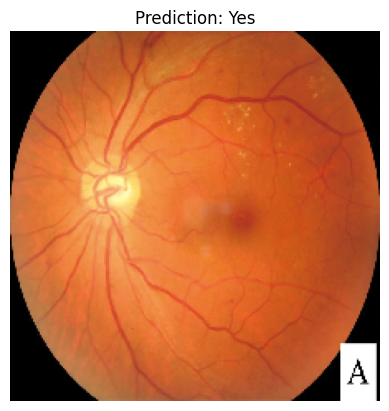

In [57]:
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()

In [58]:
img_path = "/content/Screenshot 2025-07-23 181658.png"  # replace with your image path

# Load the image with the same size as used in training
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # normalize (if you did this during training)
img_array = np.expand_dims(img_array, axis=0)  # add batch dimension

In [59]:
prediction = model.predict(img_array)

# If binary classification: use threshold
predicted_class = "Yes" if prediction[0][0] > 0.5 else "No"

print(f"Predicted class: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted class: No


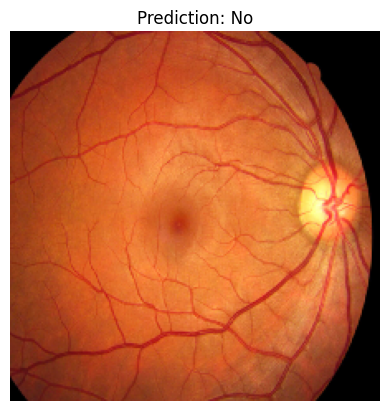

In [60]:
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()